In [1]:
# Import useful libraries
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

References for special functions

1. $\textit{scipy.special.airy}$ at https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.airy.html#scipy.special.airy
2. $\textit{scipy.special.ai\_zeros}$ at https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.ai_zeros.html#scipy.special.ai_zeros

In [2]:
# Define the Airy function, i.e., Ai(x)
def airy(x):
    return sp.special.airy(x)[0]

In [3]:
# Define the first derivative of the Airy function, i.e., Ai'(x)
def airyp(x):
    return sp.special.airy(x)[1]

In [4]:
# Store the zeros of Ai(x) and Ai'(x)
# The zeros are located in the negative part of the x-axis
# We multiply them by -1 to store their positive values
ai_z, aip_z, _, _ = sp.special.ai_zeros(1000)
ai_z = ai_z * (-1)
aip_z = aip_z * (-1)

In [5]:
# Define the main constants
# Select simple value for simplifying the calculations
# m is the particle's mass
# a, lam and rho are explained in the next chart
# With the following parameters (h^2 / 2m) = 1
hbar = 1.0
m = 0.5
F = 1.0       
lam = 1.0
rho = (hbar**2 / (2 * m * F))**(1 / 3)
rho

1.0

We will use the following notation (Robinett, 2009):

1. The potential is written as follows

\begin{equation}
    \hat{V}=\frac{\hat{p}^{\,2}}{2m}+F|x|+\lambda x.
\end{equation}

2. The odd wavefunctions are written as follows

\begin{equation}
    \psi_n^{odd}(x)=\frac{1}{\sqrt{2}}\text{sgn}(x)\psi_n(|x|)
\end{equation}

where

\begin{equation}
    \psi_n(x)^{} = N_n \,\mathrm{Ai}\left(\frac{x}{\rho} - \zeta_n\right)
\end{equation}

The constants are defined as $N_n = \frac{1}{\sqrt{\rho}\,\mathrm{Ai}'(\zeta_n)}$, $\rho = \left(\frac{\hbar^2}{2mF}\right)^{1/3}$, $\mathcal{E}_0=\rho F$ and $\zeta_n$ is the $n$-th zero of $\mathrm{Ai}(x)$.

3. The even wavefunctions are written as follows

\begin{equation}
    \psi_n^{even}(x) = \frac{1}{\sqrt{2\rho\chi_n}\mathrm{Ai}(-\chi_n)}\mathrm{Ai}\left(\frac{|x|}{\rho} - \chi_n\right)
\end{equation}

where $\chi_n$ is the $n$-th zero of $\mathrm{Ai}^\prime(x)$.



# Wavefunctions

In [6]:
# Odd wavefunction
def wf_odd(n):
    # Input: integer from 1 to n that refers to the n-th odd wavefunctions
    # Output: returns the n-th odd wavefunction \psi_n for evaluating an array of points x
    zero = ai_z[n-1]
    N = 1 / (np.sqrt(rho) * airyp(-1 * zero))
    
    def wf(x):
        x = np.array(x)
        
        return N / np.sqrt(2) * np.where(
            x >= 0,
            airy((x / rho) - zero),
            -1 * airy(-1 * (x / rho) - zero)
        )
    
    return wf

In [7]:
# Even wavefunction
def wf_even(n):
    # Input: integer from 1 to n that refers to the n-th even wavefunctions
    # Output: returns the n-th even wavefunction \psi_n for evaluating an array of points x
    zero = aip_z[n-1]
    N = 1 / (np.sqrt(2 * rho * zero) * airy(-1 * zero))
    
    def wf(x):
        x = np.array(x)
        
        return N * airy((np.abs(x) / rho) - zero)
    
    return wf

# Unperturbed energies

We will use the following notation (Robinett, 2009):

1. The odd energies are defined as 

\begin{equation}
    E_n^{odd} = \rho F \zeta_n
\end{equation}

2. The even energies are defined as follows

\begin{equation}
    E_n^{even} = \rho F \chi_n
\end{equation}


In [8]:
# Odd energies
e_odd = ai_z * rho * F
# Even energies
e_even = aip_z * rho * F

# Examples

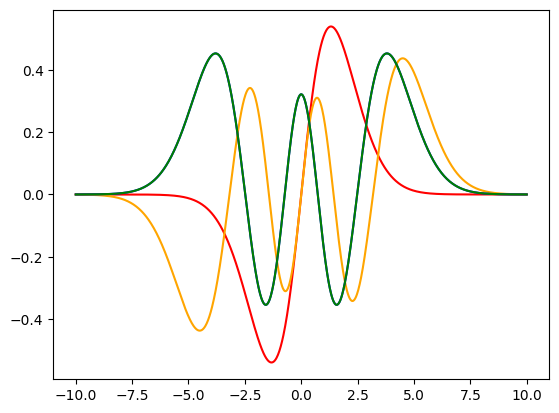

In [9]:
# Plot some wavefunctions to appreciate their symmetry
xdom = np.linspace(-10,10,1000)
plt.plot(xdom, wf_odd(1)(xdom), color = "red")
plt.plot(xdom, wf_odd(3)(xdom), color = "orange")
plt.plot(xdom, wf_even(3)(xdom), color = "blue")
plt.plot(xdom, wf_even(3)(xdom), color = "green")

In [10]:
# Check the normalization condition of an odd wavefunction
result, error = sp.integrate.quad(lambda x: wf_odd(1)(x) * wf_odd(1)(x), -500, 500)
result, error

(0.9999999999999997, 2.2945763102010202e-10)

In [11]:
# Check the normalization condition of an even wavefunction
result2, error2 = sp.integrate.quad(lambda x: wf_even(3)(x) * wf_even(1)(x), -500, 500)
result2, error2

(1.3903808659954109e-15, 9.97648372930409e-10)

In [12]:
# Calculate a matrix element
result3, error3 = sp.integrate.quad(lambda x: wf_even(1)(x) * x * wf_odd(3)(x), -25, 25)
result3

0.02171891008104246

# Python functions for perturbative analysis

In [13]:
# Calculate matrix elements
def matrix_element(psi1, f, psi2):
    # Input: three functions psi1, f and psi for the matrix element <psi1|f|psi2>
    # Output: numerical value of the matrix element
    # Integration interval is [-65, 65] as wavefunctions have negligible values in the extrema of those intervals
    # We requiere the interval [-65, 65] for Rayleight Schrodinger calculation for states with big values of n
    return sp.integrate.quad(lambda x: psi1(x) * f(x) * psi2(x), -65, 65)[0]

## Rayleight-Schrodinger correction

In [14]:
# Second correction of energy by standard perturbation theory using infinite sums
# Because of parity, first orden corrections are zero. 
# In second order, nonzero matrix elements occur between wavefuntions of opposite parity.
def E2_RS(parity, n, M):
    # Input: odd or even parity, n-th number for the n-th wavefunction, and the upper limit M for the sum
    # Output: numerical value of the second order correction to energy
    # Note that the matrix element is <psi1|f|psi2>, where f(x) = x
    sum = 0
    if parity == "even":
        for i in range(1, M):
            sum = sum + lam**2 * (matrix_element(wf_odd(i), lambda x: x, wf_even(n))**2 / (e_even[n-1] - e_odd[i-1]))
    elif parity == "odd":
        for i in range(1, M):
            sum = sum + lam**2 * (matrix_element(wf_even(i), lambda x: x, wf_odd(n))**2 / (e_odd[n-1] - e_even[i-1]))
    return sum

In [15]:
# Second order correction energy for the 1st even wavefunction
E2_RS("even", 1, 25)

np.float64(-0.565996086968307)

In [16]:
# Second order correction energy for the 1st odd wavefunction
E2_RS("odd", 1, 25)

np.float64(-1.818527985421104)

## Exact energy correction

We will use the following notation (Robinett, 2009):
\begin{equation}
    E_{n,odd}^{(2)} = -\frac{7}{9}\left(\frac{\lambda}{F}\right)^2 \left(\zeta_n\mathcal{E}_0\right)
\end{equation}

\begin{equation}
    E_{n,even}^{(2)} = -\frac{5}{9}\left(\frac{\lambda}{F}\right)^2 \left(\chi_n\mathcal{E}_0\right)
\end{equation}

In [17]:
def E2_exact(parity, n):
    if parity == "odd":
        return -7 / 9 * (lam / F)**2 * e_odd[n-1]
    if parity == "even":
        return -5 / 9 * (lam / F)**2 * e_even[n-1]

In [18]:
# Comparison of energy corrections for the 1st even wavefunction
print(E2_exact("even", 1))
print(E2_RS("even",1,25))

-0.5659960953597064
-0.565996086968307


In [19]:
# Comparison of energy corrections for the 1st odd wavefunction 
print(E2_exact("odd", 1))
print(E2_RS("odd", 1, 25))

-1.8185279859131525
-1.818527985421104


## Dalgarno-Lewis correction

In [20]:
# Second correction of energy by Dalgarno Lewis equation
def E2_DL(parity, n):
    # Input: odd or even type, n-th number for the n-th wavefunction
    # Output: numerical value of the second order correction to energy
    
    # Depending on parity, select wavefunction and ground energy
    if parity == "odd":
        E0 = e_odd[n-1]
        psi_func = wf_odd(n)
    else:
        E0 = e_even[n-1]
        psi_func = wf_even(n)

    # Dalgarno Lewis system
    # We want to solve -u'' + (2m/hbar^2)[V(x) - E0]u = -(2m/hbar^2) lamba * x * psi
    def system_edo(x, y):
        u, du = y
        # V(x) = F * x (for x > 0)
        term_v = (F * x - E0) * u
        term_source = (lam * x) * psi_func(x)
        
        d2u = (term_v + term_source) * (2 * m / hbar**2)
        return [du, d2u]

    def border_conditions(ya, yb):
        if parity == "odd":
            # For the odd state, the correction u must be even respect to x*psi
            return [ya[1], yb[0]] # u'(0)=0 y u(inf)=0
        else:
            # For the even state, the correction u must be odd respecto to x*psi
            return [ya[0], yb[0]] # u(0)=0 y u(inf)=0

    # Numerical resolution of Dalgarno Lewis equation
    # x_max = 25.5 is enought for the 25-th wavefunction
    x_max = 30 * rho
    x_grid = np.linspace(0, x_max, 1000)
    y_guess = np.zeros((2, x_grid.size))
    
    solucion = sp.integrate.solve_bvp(system_edo, border_conditions, x_grid, y_guess, max_nodes=100000, tol=1e-6)
    
    if not solucion.success:
        return "Error en la convergencia del solver: " + solucion.message

    # Calculate second order correction E2 = 2 * <psi | H' | u>
    # The factor 2 is because we integrated from 0 to inf, but the problem is from -inf to inf
    def integrando_E2(x):
        # u(x) es solucion.sol(x)[0]
        return psi_func(x) * (lam * x) * solucion.sol(x)[0]

    E2_half, _ = sp.integrate.quad(integrando_E2, 0, x_max)
    
    return 2.0 * E2_half

In [21]:
wf_even(25)(30)

np.float64(1.8030447706810453e-06)

In [22]:
# Comparison of energy corrections for the 1st even wavefunction
l = 25
print(E2_exact("odd", l))
print(E2_RS("odd",l,50))
print(E2_DL("odd",l))

-18.566772354305716


C:\Users\Dayco\AppData\Local\Temp\ipykernel_21676\3308706934.py:7: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  return sp.integrate.quad(lambda x: psi1(x) * f(x) * psi2(x), -65, 65)[0]


-18.566772349117645
-18.56667162612831


In [23]:
# Comparison of energy corrections for the 1st even wavefunction
print(E2_exact("even", 1))
print(E2_RS("even",1,25))
print(E2_DL("even",1))

-0.5659960953597064
-0.565996086968307
-0.5659960936271563


In [24]:
# Comparison of energy corrections for the 1st odd wavefunction 
print(E2_exact("odd", 1))
print(E2_RS("odd", 1, 25))
print(E2_DL("odd", 1))

-1.8185279859131525
-1.818527985421104
-1.8185279483362726


# Graphics of perturbative analysis

In [25]:
# Number of points
N = 25
# Interval in x
x_interval = np.arange(1, N + 1)

In [26]:
# Rayleight-Schrodinger
E2_even_RS = np.zeros(N)
E2_odd_RS = np.zeros(N)

for i in range(0, N):
    E2_even_RS[i] = E2_RS("even", i + 1, 100)
    E2_odd_RS[i] = E2_RS("odd", i + 1, 100)

C:\Users\Dayco\AppData\Local\Temp\ipykernel_21676\3308706934.py:7: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  return sp.integrate.quad(lambda x: psi1(x) * f(x) * psi2(x), -65, 65)[0]


In [27]:
# Exact
E2_even_EX = np.zeros(N)
E2_odd_EX = np.zeros(N)

for i in range(0, N):
    E2_even_EX[i] = E2_exact("even", i + 1)
    E2_odd_EX[i] = E2_exact("odd", i + 1)

In [28]:
# Dalgarno-Lewis
E2_even_DL = np.zeros(N)
E2_odd_DL = np.zeros(N)

for i in range(0, N):
    E2_even_DL[i] = E2_DL("even", i + 1)
    E2_odd_DL[i] = E2_DL("odd", i + 1)

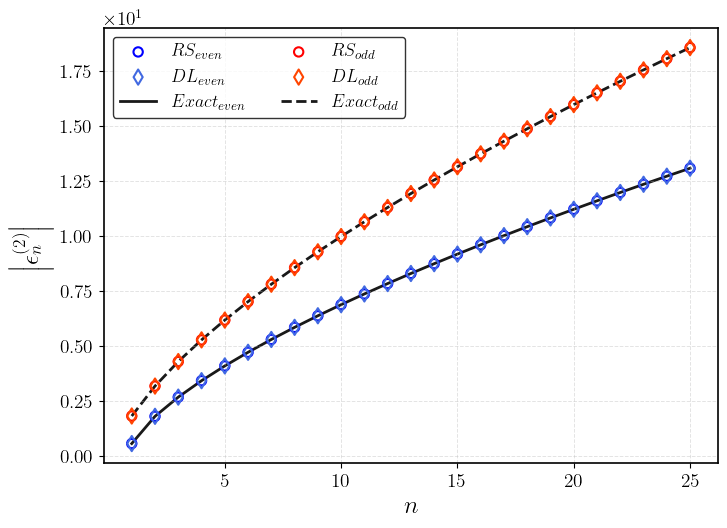

In [67]:
# Activate Latex style
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 14,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "legend.fontsize": 13,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "axes.linewidth": 1.2,
})

fig, ax = plt.subplots(figsize=(7.5,5.5))

# ============================================================
# EVEN STATES  -> BLUE
# ============================================================

# RS even
ax.scatter(
    x_interval,
    np.abs(E2_even_RS),
    color='blue',
    marker='o',
    s=45,
    facecolors='none',
    linewidths=1.5,
    label=r'$RS_{even}$',
    zorder = 2
)

# DL even
ax.scatter(
    x_interval,
    np.abs(E2_even_DL),
    color='royalblue',
    marker='d',
    s=60,
    facecolors='none',
    linewidths=1.5,
    label=r'$DL_{even}$',
    zorder = 2
)

# Exact even
ax.plot(
    x_interval,
    np.abs(E2_even_EX),
    color='black',
    linewidth=2.0,
    linestyle='-',
    alpha=0.9,
    label=r'$Exact_{even}$',
    zorder = 1
)

# ============================================================
# ODD STATES -> RED
# ============================================================

# RS odd
ax.scatter(
    x_interval,
    np.abs(E2_odd_RS),
    color='red',
    marker='o',
    s=45,
    facecolors='none',
    linewidths=1.5,
    label=r'$RS_{odd}$',
    zorder = 2
)

# DL odd
ax.scatter(
    x_interval,
    np.abs(E2_odd_DL),
    color='orangered',
    marker='d',
    s=60,
    facecolors='none',
    linewidths=1.5,
    label=r'$DL_{odd}$',
    zorder = 2
)

# Exact odd
ax.plot(
    x_interval,
    np.abs(E2_odd_EX),
    color='black',
    linewidth=2.0,
    linestyle='--',
    alpha=0.9,
    label=r'$Exact_{odd}$',
    zorder = 1
)

# ============================================================
# Labels and styling
# ============================================================

ax.set_xlabel(r"$n$")
ax.set_ylabel(r"$\left|\epsilon_n^{(2)}\right|$")

ax.set_xticks([5, 10, 15, 20, 25])

# Scientific notation
ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

# Better grid
ax.grid(
    True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.35
)

# Legend
ax.legend(
    frameon=True,
    fancybox=True,
    edgecolor='black',
    ncol=2
)

# Tight layout
plt.tight_layout()

# Save
plt.savefig(
    "convergencia_E2.pdf",
    bbox_inches='tight',
    transparent=True
)

# Save as PDF
plt.savefig("new_second_corrections.pdf", bbox_inches='tight', transparent=True)

plt.show()

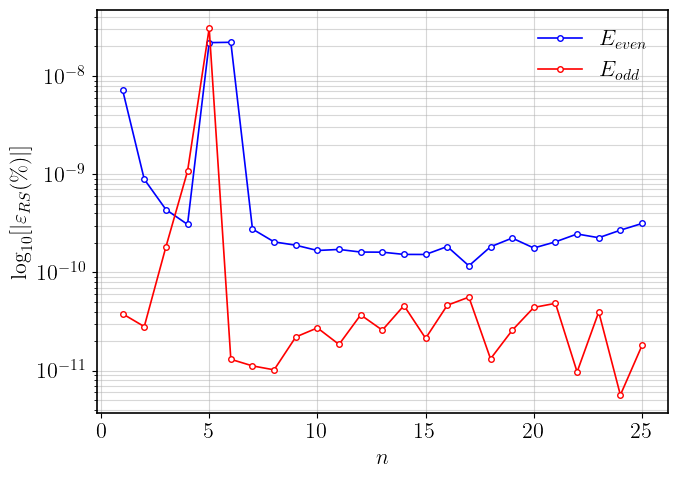

In [38]:
# Relative deviation of Rayleigh-Schrodinger
relative_error_evenRS = np.where(E2_even_EX != 0,
              np.abs(E2_even_RS - E2_even_EX) / np.abs(E2_even_EX) * 100,
              np.nan)

relative_error_oddRS = np.where(E2_odd_EX != 0,
              np.abs(E2_odd_RS - E2_odd_EX) / np.abs(E2_odd_EX) * 100,
              np.nan)

fig, ax = plt.subplots(figsize=(7,5))

ax.plot(x_interval, relative_error_evenRS,
        color='blue',
        marker='o',
        markersize=4,
        markerfacecolor='white',
        linewidth=1.2,
        label= r"$E_{even}$")


ax.plot(x_interval, relative_error_oddRS,
        color='red',
        marker='o',
        markersize=4,
        markerfacecolor='white',
        linewidth=1.2,
        label= r"$E_{odd}$")

ax.set_xlabel(r"$n$")
ax.set_ylabel(r"$\log_{10}[|\varepsilon_{RS}(\%)|$]")

ax.set_xticks([0, 5, 10, 15, 20, 25])

ax.grid(True, which="both", alpha=0.5)

ax.legend(frameon=False)

plt.yscale('log')

plt.tight_layout()

# Save as PDF
plt.savefig("new_deviation_RS.pdf", bbox_inches='tight', transparent=True)

plt.show()

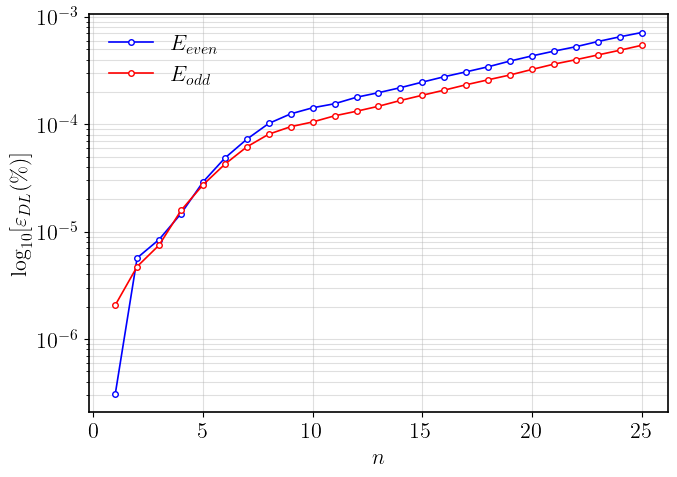

In [37]:
# Relative deviation of Dalgarno Lewis
relative_error_evenDL = np.where(E2_even_EX != 0,
              np.abs(E2_even_DL - E2_even_EX) / np.abs(E2_even_EX) * 100,
              np.nan)

relative_error_oddDL = np.where(E2_odd_EX != 0,
              np.abs(E2_odd_DL - E2_odd_EX) / np.abs(E2_odd_EX) * 100,
              np.nan)

fig, ax = plt.subplots(figsize=(7,5))

ax.plot(x_interval, relative_error_evenDL,
        color='blue',
        marker='o',
        markersize=4,
        markerfacecolor='white',
        linewidth=1.2,
        label= r"$E_{even}$")


ax.plot(x_interval, relative_error_oddDL,
        color='red',
        marker='o',
        markersize=4,
        markerfacecolor='white',
        linewidth=1.2,
        label= r"$E_{odd}$")

ax.set_xlabel(r"$n$")
ax.set_ylabel(r"$\log_{10}[\varepsilon_{DL}(\%)$]")

ax.set_xticks([0, 5, 10, 15, 20, 25])

ax.grid(True, which="both", alpha=0.4)

ax.legend(frameon=False)

plt.yscale('log')

plt.tight_layout()

# Save as PDF
plt.savefig("new_deviation_DL.pdf", bbox_inches='tight', transparent=True)

plt.show()

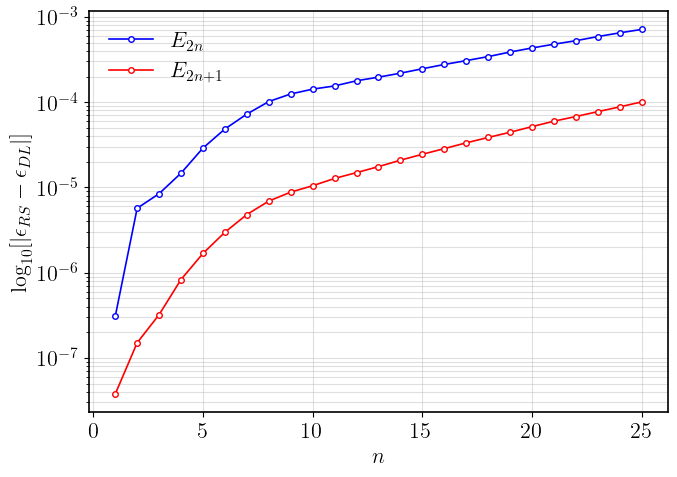

In [32]:
# Error difference of Dalgarno and Rayleight Schrodinger
relative_error_evenRSDL = np.abs(E2_even_DL - E2_even_RS)

relative_error_oddDL = np.abs(E2_odd_DL - E2_odd_RS)

fig, ax = plt.subplots(figsize=(7,5))

ax.plot(x_interval, relative_error_evenDL,
        color='blue',
        marker='o',
        markersize=4,
        markerfacecolor='white',
        linewidth=1.2,
        label= r"$E_{2n}$")


ax.plot(x_interval, relative_error_oddDL,
        color='red',
        marker='o',
        markersize=4,
        markerfacecolor='white',
        linewidth=1.2,
        label= r"$E_{2n+1}$")

ax.set_xlabel(r"$n$")
ax.set_ylabel(r"$\log_{10}[|\epsilon_{RS} - \epsilon_{DL}|$]")

ax.set_xticks([0, 5, 10, 15, 20, 25])

ax.grid(True, which="both", alpha=0.4)

ax.legend(frameon=False)

plt.yscale('log')

plt.tight_layout()

# Save as PDF
plt.savefig("deviation_RS.pdf", bbox_inches='tight', transparent=True)

plt.show()